'\naxs[2,2].set_title("jy vs t")\naxs[2,2].plot(list_t, j_y)\naxs[2,2].grid()\n'

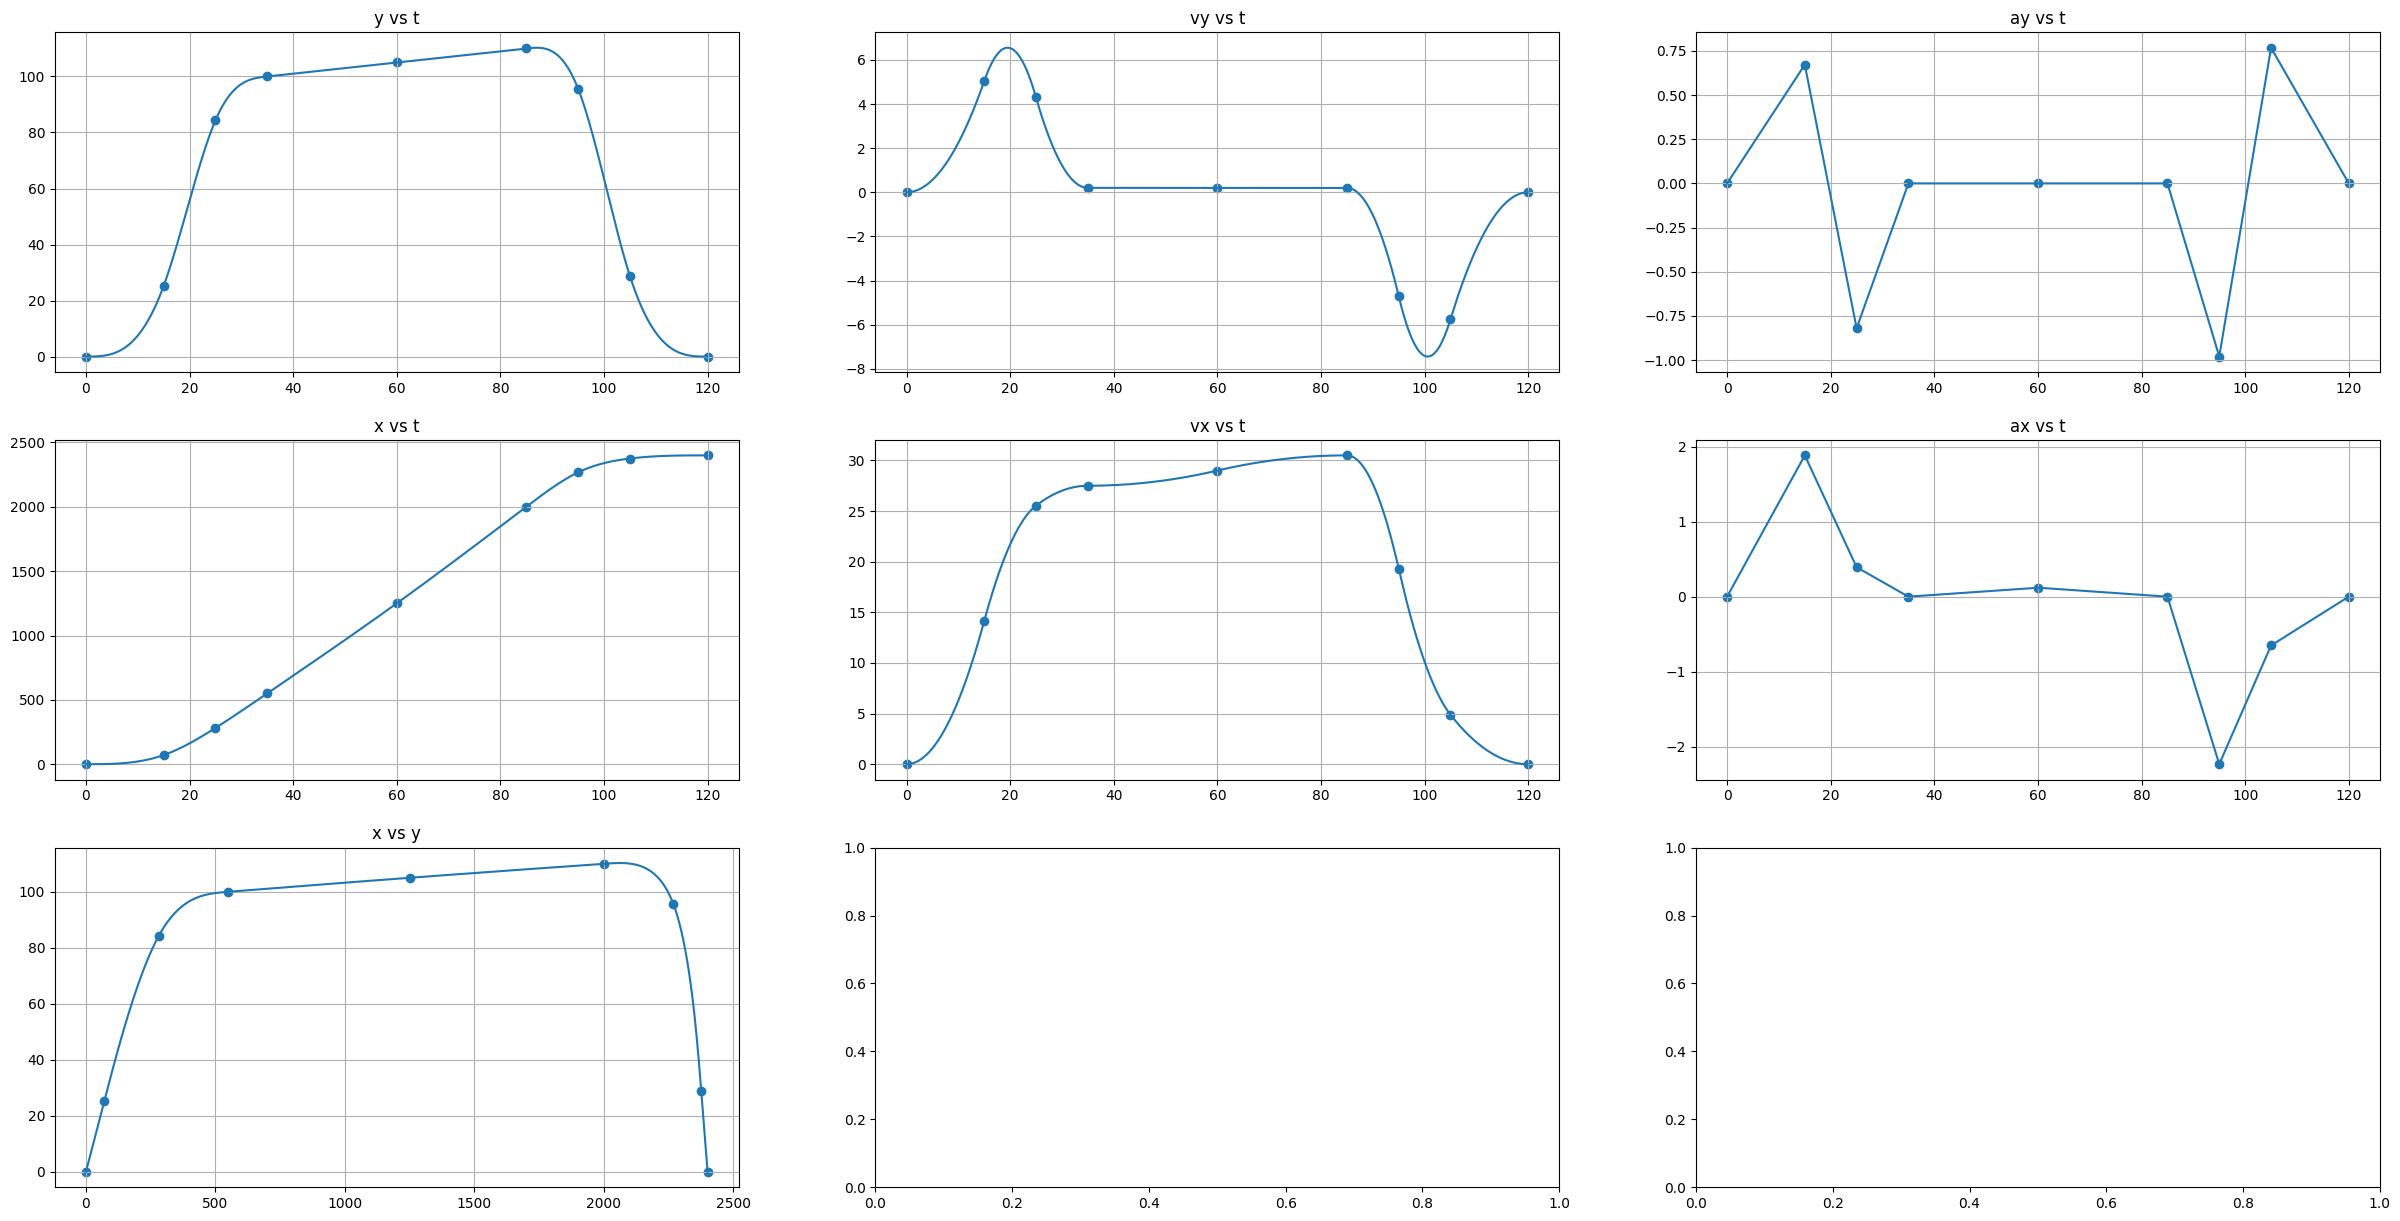

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# from Scripts.mission_profile import MissionProfile
from Scripts.Mission_Profile.mission_profile import MissionProfileLinearAcc


m1 = MissionProfileLinearAcc("profile")

m1.add_segment(15, "Takeoff")
m1.add_segment(10, "Climb1")
m1.add_segment(10, "Climb2")
m1.add_segment(25, "cruise1")
m1.add_segment(25, "cruise2")
m1.add_segment(10, "decent1")
m1.add_segment(10, "decent2")
m1.add_segment(15, "land")

# Takeoff
m1.add_constraint(0, "x", 0)
m1.add_constraint(0, "y", 0)
m1.add_constraint(0, "vx", 0)
m1.add_constraint(0, "vy", 0)
m1.add_constraint(0, "ax", 0)
m1.add_constraint(0, "ay", 0)

# Cruise
m1.add_constraint(550000, "x", 3)
m1.add_constraint(100000, "y", 3)
m1.add_constraint(0, "ax", 3)
m1.add_constraint(0, "ay", 3)
m1.add_constraint(1250000, "x", 4)
m1.add_constraint(105000, "y", 4)
m1.add_constraint(2000000, "x", 5)
m1.add_constraint(0, "ax", 5)
m1.add_constraint(110000, "y", 5)
m1.add_constraint(0, "ay", 5)

# Decent
m1.add_constraint(2400000, "x", 8)
m1.add_constraint(0, "y", 8)
m1.add_constraint(0, "vx", 8)
m1.add_constraint(0, "vy", 8)
m1.add_constraint(0, "ax", 8)
m1.add_constraint(0, "ay", 8)


m1.solve_kinematics()


list_t = np.arange(0, m1.nodes[-1], 0.1)

x = np.zeros(len(list_t))
y = np.zeros(len(list_t))
v_x = np.zeros(len(list_t))
v_y = np.zeros(len(list_t))
a_x = np.zeros(len(list_t))
a_y = np.zeros(len(list_t))

for i, t in enumerate(list_t):
    p,v,a = m1.time_solve(t)
    x[i] = p[0]
    y[i] = p[1]
    v_x[i] = v[0]
    v_y[i] = v[1]
    a_x[i] = a[0]
    a_y[i] = a[1]

'''
m1 = MissionProfile("m1", 1, 0, 0)

m1.add_segment("takeoff",2,0,2,0,1)
m1.add_segment("climb",15,550000,100000,300,0)
m1.add_segment("cruise",50,2000000,110000,300,0)
m1.add_segment("descent",10,2200000,50000,0,0)
m1.add_segment("loiter",5,2200000,50000,0,0)
m1.add_segment("land",10,2400000,0,0,0)


list_t = np.arange(0, m1.t_values[-1], 0.1)

x = np.zeros(len(list_t))
y = np.zeros(len(list_t))
v_x = np.zeros(len(list_t))
v_y = np.zeros(len(list_t))
a_x = np.zeros(len(list_t))
a_y = np.zeros(len(list_t))
j_x = np.zeros(len(list_t))
j_y = np.zeros(len(list_t))

for i, t in enumerate(list_t):
    x_result, y_result, name = m1.time_solve(t)
    x[i] = x_result[0]
    y[i] = y_result[0]
    v_x[i] = x_result[1]
    v_y[i] = y_result[1]
    a_x[i] = x_result[2]
    a_y[i] = y_result[2]
    j_x[i] = x_result[3]
    j_y[i] = y_result[3]
    
'''

fig, axs = plt.subplots(3, 3)

fig.set_figheight(15)
fig.set_figwidth(30)

axs[0,0].set_title("y vs t")
axs[0,0].plot(list_t, y/1000)
axs[0,0].scatter(m1.nodes,m1.py/1000)
axs[0,0].grid()

axs[1,0].set_title("x vs t")
axs[1,0].plot(list_t, x/1000)
axs[1,0].scatter(m1.nodes,m1.px/1000)
axs[1,0].grid()

axs[2,0].set_title("x vs y")
axs[2,0].plot(x/1000, y/1000)
axs[2,0].scatter(m1.px/1000,m1.py/1000)
axs[2,0].grid()

axs[0,1].set_title("vy vs t")
axs[0,1].plot(list_t, v_y/1000)
axs[0,1].scatter(m1.nodes,m1.vy/1000)
axs[0,1].grid()

axs[1,1].set_title("vx vs t")
axs[1,1].plot(list_t, v_x/1000)
axs[1,1].scatter(m1.nodes,m1.vx/1000)
axs[1,1].grid()
'''
axs[2,1].set_title("jx vs t")
axs[2,1].plot(list_t, j_x)
axs[2,1].grid()
'''
axs[0,2].set_title("ay vs t")
axs[0,2].plot(list_t, a_y/1000)
axs[0,2].scatter(m1.nodes,m1.ay/1000)
axs[0,2].grid()

axs[1,2].set_title("ax vs t")
axs[1,2].plot(list_t, a_x/1000)
axs[1,2].scatter(m1.nodes,m1.ax/1000)
axs[1,2].grid()
'''
axs[2,2].set_title("jy vs t")
axs[2,2].plot(list_t, j_y)
axs[2,2].grid()
'''


 

In [3]:
# Determine masses; moments of inertia; and surface area (for drag)

# Build vehicle coordinate system

# use prop data to determine acceleration; 70% power; 1 dimension

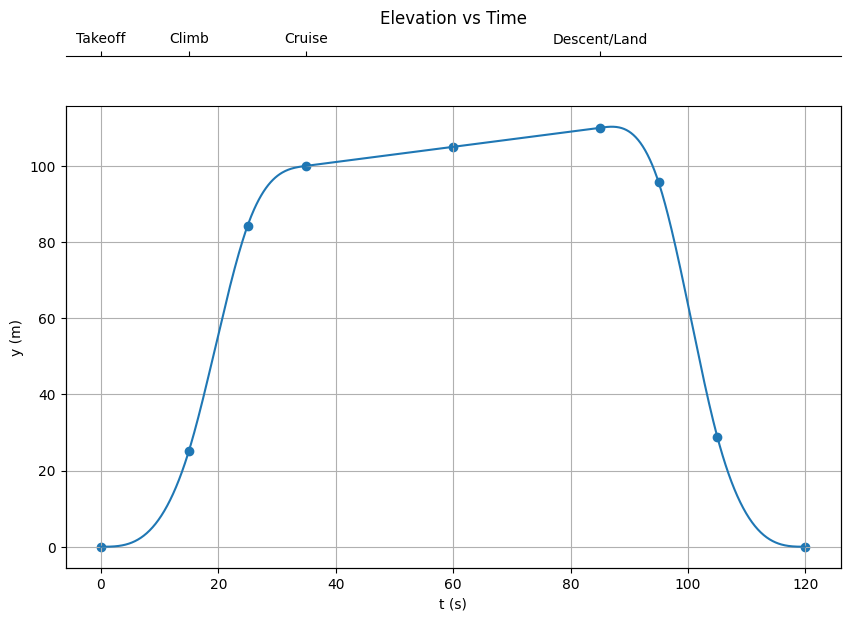

In [6]:
plt.figure(figsize=(10, 6))
plt.title("Elevation vs Time")
plt.plot(list_t, y / 1000)
plt.scatter(m1.nodes, m1.py / 1000)
plt.xlabel("t (s)")
plt.ylabel("y (m)")
plt.grid()

# Create aggregated section labels: takeoff, climb, cruise, descent+land
# Group indices: (start_segment_index, end_segment_index_exclusive, label)
groups = [
    (0, 1, "Takeoff"),
    (1, 3, "Climb"),
    (3, 5, "Cruise"),
    (5, 8, "Descent/Land")
]

# Use m1.nodes (segment boundary times). Ensure it's a numpy array for indexing.
import numpy as _np

nodes = _np.array(m1.nodes)

start_ticks = []
start_labels = []
for start_idx, end_idx, label in groups:
    # clip start index to available range
    start_idx_clipped = max(0, min(start_idx, len(nodes) - 1))
    start_t = nodes[start_idx_clipped]
    start_ticks.append(start_t)
    start_labels.append(label)

ax = plt.gca()
# Add secondary x-axis to display labels at the segment start nodes without replacing original numeric ticks.
sec = ax.twiny()
sec.set_xlim(ax.get_xlim())
sec.set_xticks(start_ticks)
sec.set_xticklabels(start_labels, rotation=15, ha='left')
sec.spines['top'].set_position(('outward', 36))
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Down Range Position vs Time")
plt.plot(list_t, x / 1000)
plt.scatter(m1.nodes, m1.px / 1000)
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.grid()
plt.show()

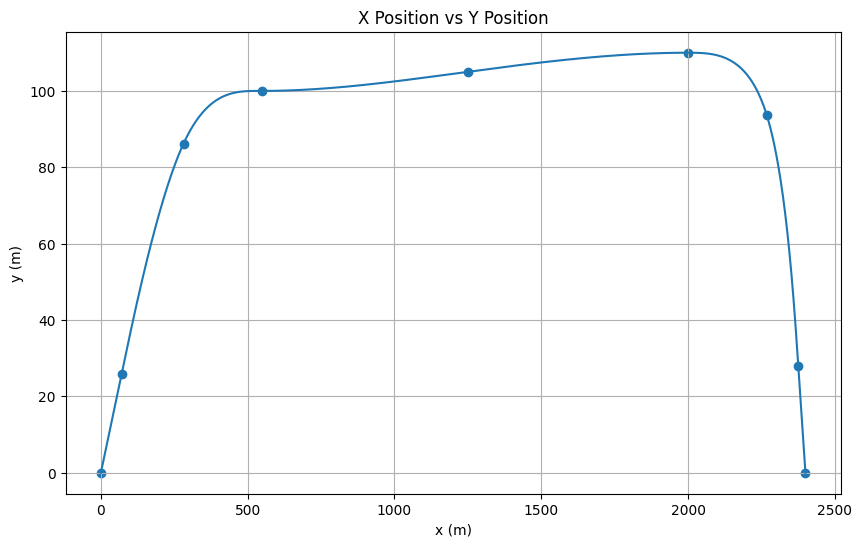

In [5]:
plt.figure(figsize=(10, 6))
plt.title("Elevation vs Down Range Position")
plt.plot(x / 1000, y / 1000)
plt.scatter(m1.px / 1000, m1.py / 1000)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.grid()
plt.show()

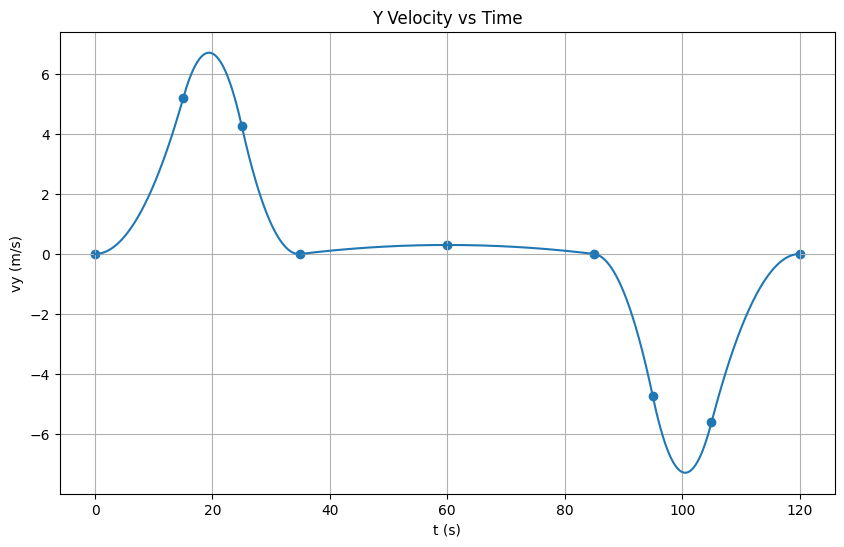

In [6]:
plt.figure(figsize=(10, 6))
plt.title("Y Velocity vs Time")
plt.plot(list_t, v_y / 1000)
plt.scatter(m1.nodes, m1.vy / 1000)
plt.xlabel("t (s)")
plt.ylabel("vy (m/s)")
plt.grid()
plt.show()

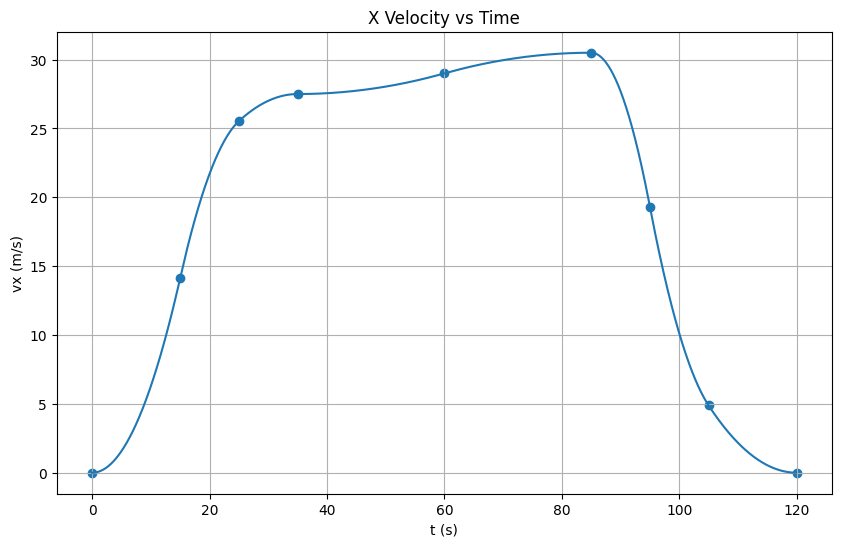

In [7]:
plt.figure(figsize=(10, 6))
plt.title("X Velocity vs Time")
plt.plot(list_t, v_x / 1000)
plt.scatter(m1.nodes, m1.vx / 1000)
plt.xlabel("t (s)")
plt.ylabel("vx (m/s)")
plt.grid()
plt.show()

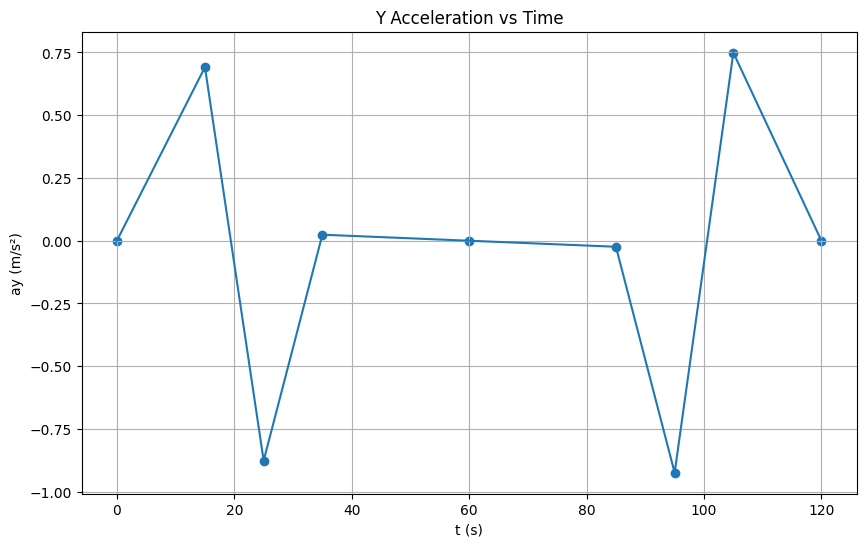

In [12]:
plt.figure(figsize=(10, 6))
plt.title("Y Acceleration vs Time")
plt.plot(list_t, a_y / 1000)
plt.scatter(m1.nodes, m1.ay / 1000)
plt.xlabel("t (s)")
plt.ylabel("ay (m/s²)")
plt.grid()
plt.show()

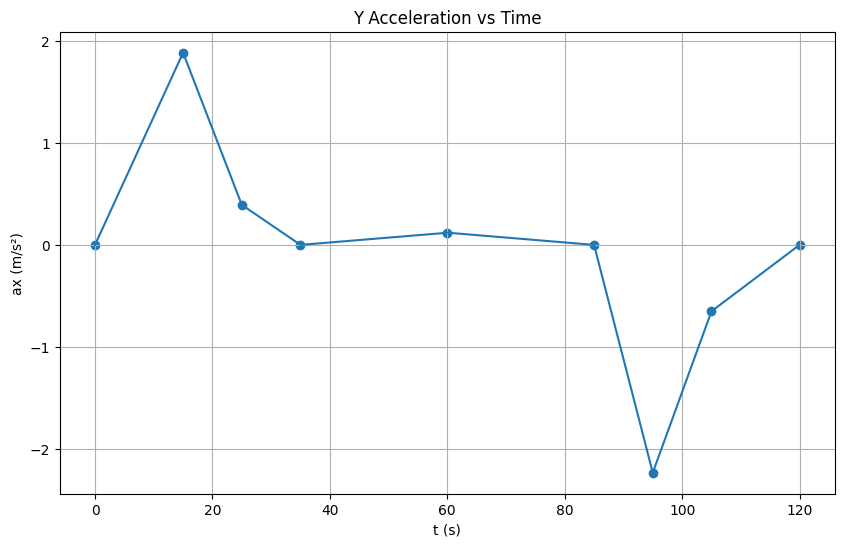

In [11]:
plt.figure(figsize=(10, 6))
plt.title("Y Acceleration vs Time")
plt.plot(list_t, a_x / 1000)
plt.scatter(m1.nodes, m1.ax / 1000)
plt.xlabel("t (s)")
plt.ylabel("ax (m/s²)")
plt.grid()
plt.show()
